<a href="https://colab.research.google.com/github/pavansaipps2-cmd/ML-PROJECT/blob/main/PROJECT_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (100, 10)
readmitted_30days
1    82
0    18
Name: count, dtype: int64
Accuracy: 0.5
ROC-AUC: 0.578125
              precision    recall  f1-score   support

           0       0.12      0.25      0.17         4
           1       0.75      0.56      0.64        16

    accuracy                           0.50        20
   macro avg       0.44      0.41      0.40        20
weighted avg       0.62      0.50      0.55        20


Feature Coefficients (Elastic Net):
age                           0.893674
num_medications               0.819689
prev_admissions               0.469987
length_of_stay_days           0.433944
discharge_type_Transferred    0.399121
discharge_type_Home           0.256133
glucose_level                -0.182649
num_diagnoses                 0.181415
discharge_type_Home Health   -0.149351
has_diabetes                  0.086998
bmi                           0.000000
dtype: float64


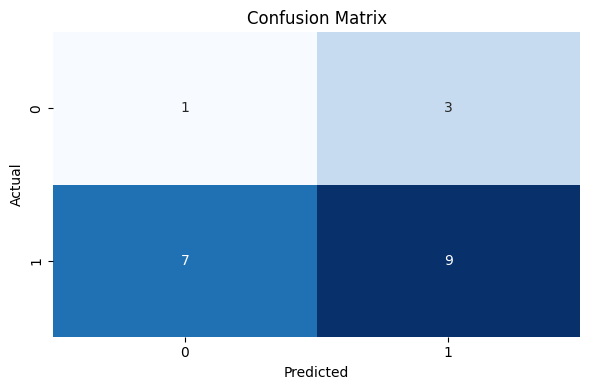

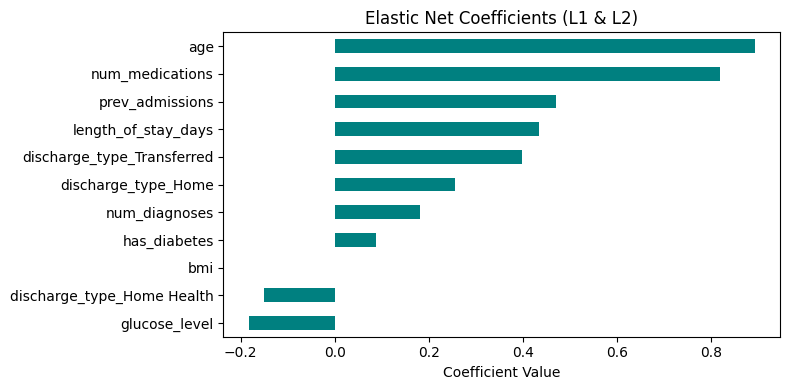

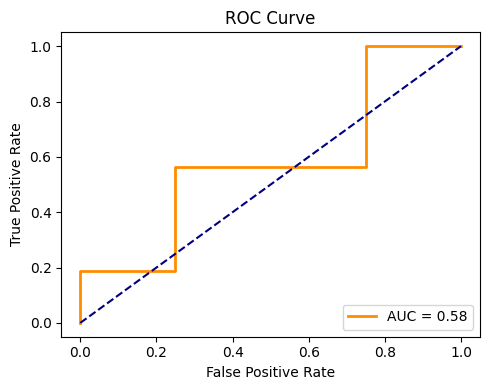

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

filename = 'hospital_readmission.csv'
df = pd.read_csv(filename)
print("Dataset Shape:", df.shape)
print(df['readmitted_30days'].value_counts())

df_encoded = pd.get_dummies(df, columns=['discharge_type'], drop_first=True)

X = df_encoded.drop('readmitted_30days', axis=1)
y = df_encoded['readmitted_30days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=1.0, class_weight='balanced', max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, zero_division=0))

coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("\nFeature Coefficients (Elastic Net):")
print(coefficients)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
coefficients.sort_values().plot(kind='barh', color='teal')
plt.title('Elastic Net Coefficients (L1 & L2)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

--- Missing Values Check ---
age                    0
length_of_stay_days    0
num_diagnoses          0
num_medications        0
prev_admissions        0
glucose_level          0
bmi                    0
has_diabetes           0
discharge_type         0
readmitted_30days      0
dtype: int64
Total missing values in dataset: 0

--- Outlier Detection (IQR Method) ---
age                     0
length_of_stay_days     0
num_diagnoses           4
num_medications         1
prev_admissions         5
glucose_level           0
bmi                     1
has_diabetes            0
readmitted_30days      18
dtype: int64


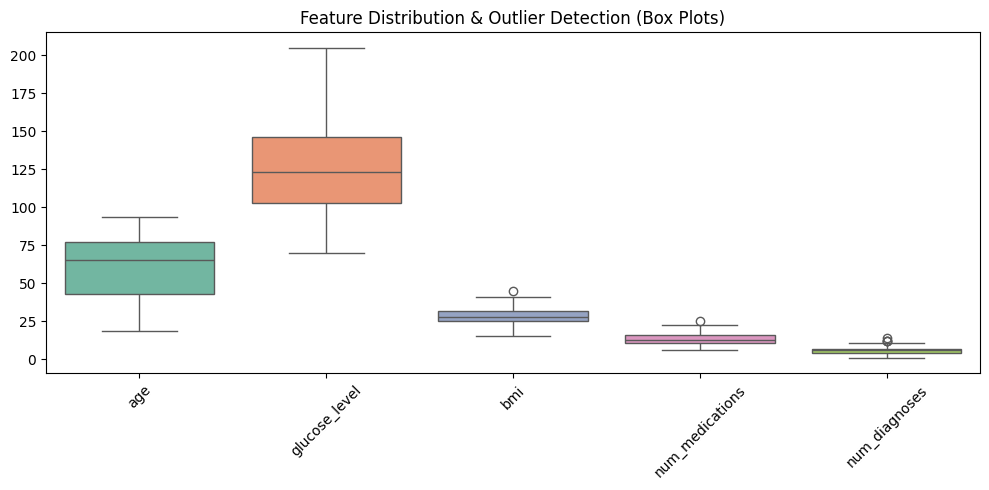

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('hospital_readmission.csv')

# 1. Check for Missing Values
print("--- Missing Values Check ---")
missing_values = df.isnull().sum()
print(missing_values)
print(f"Total missing values in dataset: {missing_values.sum()}")

# 2. Check for Outliers using Interquartile Range (IQR) Method
print("\n--- Outlier Detection (IQR Method) ---")
numerical_cols = df.select_dtypes(include=[np.number]).columns
outliers_count = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count[col] = len(outliers)

print(pd.Series(outliers_count))

# 3. Visualize Outliers using Box Plots
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['age', 'glucose_level', 'bmi', 'num_medications', 'num_diagnoses']], palette="Set2")
plt.title('Feature Distribution & Outlier Detection (Box Plots)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()